# 3 · Telling identical hens apart — colour identity + tracking

Here's the tricky part. White layer hens look **identical**. Most systems solve this with an expensive re-identification neural network. We use something far cheaper that runs on a Raspberry Pi: each hen wears a small **coloured paint mark** on its back, so *colour is the identity*.

Two ideas make it robust:
1. **Tracking** follows each bird frame to frame so its identity persists even as it moves and is briefly hidden.
2. A **one-colour-per-bird rule with temporal voting** means a fleeting bad reading can't put the same colour on two birds — the five identities stay mutually exclusive.

We run our real dual-camera tracker on a short clip and produce an annotated video.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

# Locate the repo root (folder holding pen_config.json) and make src/ + scripts/ importable.
ROOT = Path.cwd()
for _ in range(6):
    if (ROOT / "pen_config.json").exists():
        break
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "scripts"))

import cv2, json
import numpy as np
import matplotlib.pyplot as plt

DEMO = ROOT / "output" / "demo"
DEMO.mkdir(parents=True, exist_ok=True)

SEG_MODEL  = "models/poultry-seg-yolo12s-v2.pt"
POSE_MODEL = "models/hen_pose_yolo12s_aug_v6.pt"   # the freshly retrained pose model
STEM = "20260605_141702"                            # a daytime synchronized clip
CAM0 = ROOT / "dataset/treatment1/cam0" / f"{STEM}.mp4"   # top-down
CAM1 = ROOT / "dataset/treatment1/cam1" / f"{STEM}.mp4"   # lateral

def show(img_bgr, title="", w=11):
    """Show a BGR image inline."""
    h, wd = img_bgr.shape[:2]
    plt.figure(figsize=(w, w * h / wd))
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); plt.axis("off")
    if title: plt.title(title, fontsize=13)
    plt.show()

def grab(video, idx=300):
    """Read one frame from a video."""
    cap = cv2.VideoCapture(str(video)); cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, fr = cap.read(); cap.release()
    if not ok: raise RuntimeError(f"could not read frame {idx} of {video}")
    return fr


In [2]:
# track_pen.run() is our production dual-view tracker: it detects + tracks in each
# view, reads the paint colour on each mask, and fuses both views onto the pen floor.
import track_pen
cfg = json.load(open(ROOT / "pen_config.json"))

out_mp4 = DEMO / "tracking.mp4"
csv_out = DEMO / "pen_state.csv"
track_pen.run(
    cam0_path=CAM0, cam1_path=CAM1, model_path=SEG_MODEL, cfg=cfg,
    conf=0.35, iou=0.5, margin_m=0.15, show=False,
    csv_path=csv_out, walls=False, save_video=out_mp4, max_frames=120,
)
print("wrote", out_mp4)

FlashAttention is not available on this device. Using scaled_dot_product_attention instead.


Model: models/poultry-seg-yolo12s-v2.pt
Cam0 : C:\dev\poultry-vision\dataset\treatment1\cam0\20260605_141702.mp4
Cam1 : C:\dev\poultry-vision\dataset\treatment1\cam1\20260605_141702.mp4
Controls: [space] pause  [q] quit


f=    0  visible=0/5  missing=['green', 'black', 'red', 'blue', 'yellow']  feeder=...  waterer=...


f=   50  visible=3/5  missing=['green', 'black']  feeder=ok  waterer=...


f=  100  visible=3/5  missing=['green', 'black']  feeder=ok  waterer=...


Reached max-frames=120.
Video written -> C:\dev\poultry-vision\output\demo\tracking.mp4
CSV written -> C:\dev\poultry-vision\output\demo\pen_state.csv
wrote C:\dev\poultry-vision\output\demo\tracking.mp4


### A few frames from the result
Each panel is *top view | lateral view | floor map*. A hen keeps its colour label as it moves, and the floor map (right) places all birds in one shared, metric top-down frame.

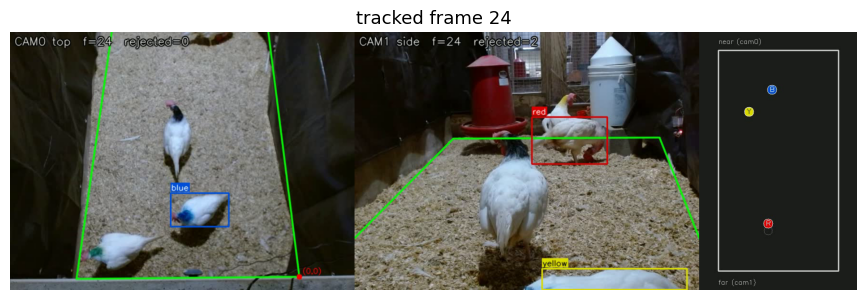

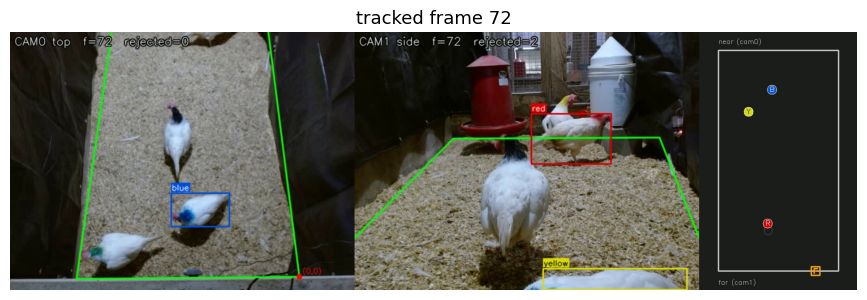

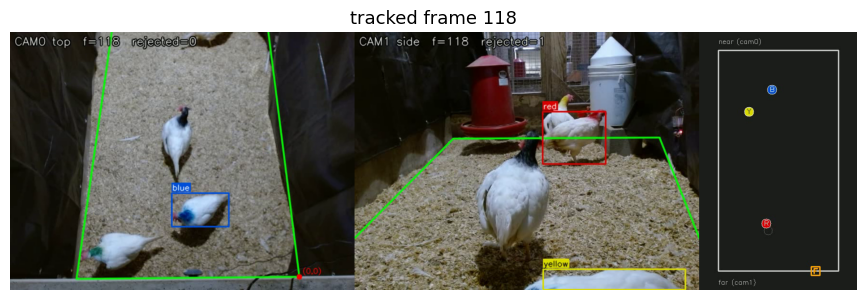

In [3]:
cap = cv2.VideoCapture(str(out_mp4))
n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
for idx in [int(n*0.2), int(n*0.6), n-2]:
    cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, idx))
    ok, fr = cap.read()
    if ok: show(fr, f"tracked frame {idx}")
cap.release()

### Why this is nice
No training a re-identification network, no cloud. A colour signature scored on each hen's mask, plus a light voting scheme, keeps identities correct over long stretches on cheap edge hardware. The shareable clip is at `output/demo/tracking.mp4`.